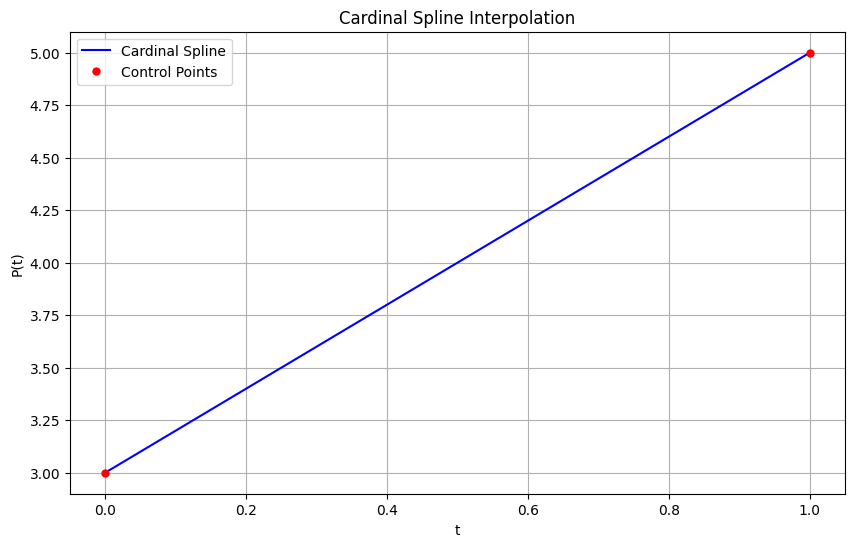

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define points
P0, P1, P2, P3 = 1, 3, 5, 7

# Create tension parameter (using -0.5 for Catmull-Rom case)
s = 0.5

# Create the Cardinal matrix
M = np.array([
    [0,        1,       0,       0],
    [-s,     0,       s,     0],
    [2*s,    s-3,   3-2*s, -s],
    [-s,     2-s,   s-2,   s]
])

# Create points vector
P = np.array([P0, P1, P2, P3])

# Create parameter t
t = np.linspace(0, 1, 100)

# Calculate points
points = []
for ti in t:
    T = np.array([1, ti, ti**2, ti**3])
    # Calculate point
    point = T @ M @ P
    points.append(point)

# Convert points to numpy array
points = np.array(points)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, points, 'b-', label='Cardinal Spline')
plt.plot([0, 1], [P1, P2], 'r.', markersize=10, label='Control Points')
plt.grid(True)
plt.xlabel('t')
plt.ylabel('P(t)')
plt.title('Cardinal Spline Interpolation')
plt.legend()
plt.show()

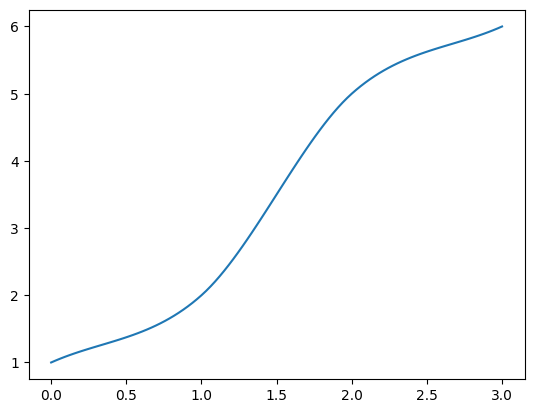

In [3]:



from typing import List


class Linalg:
    @staticmethod
    def matmul(a, b):
        """
        Multiply two matrices represented as lists of lists.
        
        Args:
            a (List[List[float]]): First matrix
            b (List[List[float]]): Second matrix
        
        Returns:
            List[List[float]]: Resulting matrix
            
        Raises:
            ValueError: If matrices cannot be multiplied due to incompatible dimensions
        """
        # Get dimensions
        a_rows = len(a)
        a_cols = len(a[0])
        b_rows = len(b)
        b_cols = len(b[0])
        
        # Check if multiplication is possible
        if a_cols != b_rows:
            raise ValueError(f"Cannot multiply matrices of dimensions ({a_rows}x{a_cols}) and ({b_rows}x{b_cols})")
        
        # Initialize result matrix with zeros
        result = [[0 for _ in range(b_cols)] for _ in range(a_rows)]
        
        # Perform matrix multiplication
        for i in range(a_rows):
            for j in range(b_cols):
                for k in range(a_cols):
                    result[i][j] += a[i][k] * b[k][j]
        
        return result

class CardinalSpline():

  def __init__(self,points:List[float],times,s=0.5):

    if len(points) < 2:
      raise ValueError("there must be at least 2 points")
    if len(times) != len(points) - 1:
      raise ValueError("len(times) must be equal len(points) - 1")

    self.matrix = [
        [0,        1,       0,       0],
        [-s,     0,       s,     0],
        [2*s,    s-3,   3-2*s, -s],
        [-s,     2-s,   s-2,   s]
    ]
    self.points = points
    self.points.insert(0,2*points[0] - points[1])
    self.points.append(2*points[-1] - points[-2])
    self.times = times
    self.n_steps = len(times)

  def get_step(self,t):
    step = 0

    i_previous = -1
    i_next = 0

  
    while True:
      if i_next >= self.n_steps-1:
          return step
      if i_previous == -1:
        if  0 <= t < self.times[i_next]:
          return step
      else:
        if  self.times[i_previous] <= t < self.times[i_next]:
          return step
      i_previous +=1
      i_next += 1
      step += 1

  def compute(self,t):

    if t < 0:
      return self.points[1]
    if t > self.times[-1]:
      return self.points[-2]

    step = self.get_step(t)
    time_so_far = self.times[step-1] if step > 0 else 0
    duration =  self.times[step] - time_so_far

    # relative time for that step (between 0 and 1)
    tr = (t - time_so_far) / duration

    T = [[1, tr, tr**2, tr**3]]
    P = [[p] for p in self.points[step:step+4]]

    return Linalg.matmul(Linalg.matmul(T, self.matrix), P)[0][0]
  
  def compute_many(self,t):
    return [self.compute(ti) for ti in t]
      
t = np.linspace(0, 3, 100)
spline = CardinalSpline([1,2,5,6],[1,2,3])
y = spline.compute_many(t)
# y = spline.compute(0)
plt.plot(t,y)
plt.show()
